# Reward-prediction evidence

**Purpose.** Keep the evidence for reward-prediction pipeline in one reproducible place. Evidence notebook, not a training notebook.

The model predicts immediate reward from the pre-action belief $b_t$ and current action $a_t$, and beats a constant-mean baseline on two held-out file splits. 

In [1]:
# move notebook to the root and check gpu availability
%cd /workspaces/tesis_v4

from pathlib import Path

# Run this notebook with the repository root as the working directory.
ROOT = Path.cwd()
if not (ROOT / 'src' / 'rwm').exists():
    raise RuntimeError('Open Jupyter from the repository root: jupyter lab --ip=0.0.0.0 --no-browser')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Change CURRENT_MODEL only; historical variants remain available for controlled comparisons.
MODEL_VARIANTS = {
    'sru_strict_dropout_seed42': ROOT / 'runs/component_refinement/sru_temporal/08_strict_observational_dropout_anchor/seed42/checkpoint_best.pt',
    'sru_strict_dropout_seed43': ROOT / 'runs/component_refinement/sru_temporal/08_strict_observational_dropout_anchor/seed43/checkpoint_best.pt',
    'sru_visible_seed42': ROOT / 'runs/component_refinement/sru_temporal/01_visible_reward_anchor/seed42/checkpoint_best.pt',
    'sru_visible_seed43': ROOT / 'runs/component_refinement/sru_temporal/01_visible_reward_anchor/seed43/checkpoint_best.pt',
    'causal_k8_seed42': ROOT / 'runs/component_refinement/causal_transformer/05_k_ablation/learned_k8_seed42/checkpoint_best.pt',
    'causal_k8_seed43': ROOT / 'runs/component_refinement/causal_transformer/05_k_ablation/learned_k8_seed43/checkpoint_best.pt',
}
CURRENT_MODEL = 'sru_strict_dropout_seed42'
CHECKPOINT = MODEL_VARIANTS[CURRENT_MODEL]
assert CHECKPOINT.exists(), f'Missing checkpoint: {CHECKPOINT}'

plt.style.use('default')
print(f'PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}')

/workspaces/tesis_v4
PyTorch: 2.7.0+cu128 | CUDA available: True


## Reproduce the anchor experiment

In [2]:
# Writes a structured run with config, dataset manifest, metrics, probes, and checkpoints. 
!python scripts/evaluation/evaluate_reward_prediction.py \
	--beta 0.1 --epochs 10 --batch-size 8 \
	--seed 42 --max-val-windows 256 \
	--cache-dir data/cache/rollout_frames_v1 \
	--reward-head-kind linear --selection-mode learned --selection-k 8 \
	--tokenizer-eval-mode mean --temporal-backend minimal_sru --sru-burn-in-steps 20 \
	--temporal-mask-enabled --temporal-mask-warmup 4 \
	--temporal-mask-horizons 1 2 4 8 12 --temporal-mask-probability 0.5 \
	--temporal-mask-ramp-epochs 2 --observation-dropout-execution pre_perception_skip \
	--out runs/evidence/reproductions/sru_strict_dropout_seed42

Run directory: runs/evidence/reproductions/sru_strict_dropout_seed42
Train: 16 files, 4040 windows
Val:   4 files, 256 windows
Training:   3%|▌              | 17/505 [00:13<06:39,  1.22it/s, avg_loss=0.5029]^C


In [ ]:
# Verify the trained checkpoint still produces distinct reward predictions for distinct actions.
!python scripts/evaluation/evaluate_reward_prediction.py \
	--checkpoint {CHECKPOINT} \
	--out runs/evidence/action_probes/{CURRENT_MODEL}

## Anchor results

Both current SRU anchors use 256 bounded validation windows, 10 epochs, $\beta=0.1$, K=8, and strict temporal observational dropout. The baseline is the training-set constant mean reward.

In [3]:
# Read the persisted results instead of duplicating experiment values in the notebook.
result_paths = [
    ROOT / 'runs/component_refinement/sru_temporal/08_strict_observational_dropout_anchor/seed42/results.json',
    ROOT / 'runs/component_refinement/sru_temporal/08_strict_observational_dropout_anchor/seed43/results.json',
]
results = pd.DataFrame([pd.read_json(path, typ='series') for path in result_paths])
results = results.rename(columns={'best_val_mse': 'val_mse', 'elapsed_s': 'time_s'})[
    ['seed', 'train_windows', 'val_windows', 'val_mse', 'baseline_mse', 'time_s']
]
results['model_baseline_ratio'] = results.val_mse / results.baseline_mse
results['improvement_pct'] = (1 - results.model_baseline_ratio) * 100
results.style.format({'val_mse': '{:.4f}', 'baseline_mse': '{:.4f}', 'model_baseline_ratio': '{:.3f}', 'improvement_pct': '{:.1f}%'})

,seed,train_windows,val_windows,val_mse,baseline_mse,time_s,model_baseline_ratio,improvement_pct
0,42,4040,256,0.5000,0.5630,451.037342,0.888,11.2%
1,43,4306,256,0.5122,0.6279,474.871575,0.816,18.4%


**Interpretation.** Both strict-dropout SRU anchors beat the constant baseline on held-out windows. The manual trace below checks whether that learned signal remains recognizable under human driving; it is qualitative evidence, not the locked benchmark.

## Review a manually driven reward trace

In [4]:
# Generate an aligned trace with the interactive command. 
# Close the game window or press Escape; the command saves the CSV.
!SDL_AUDIODRIVER=dummy rwm test-rwm-manually \
	{CHECKPOINT} \
  	--log-path runs/evidence/manual_traces/{CURRENT_MODEL}_session01.csv \
  	--fps 60

Figure(700x350)
Saved 923 aligned reward pairs to runs/evidence/manual_traces/sru_strict_dropout_seed42_session01.csv


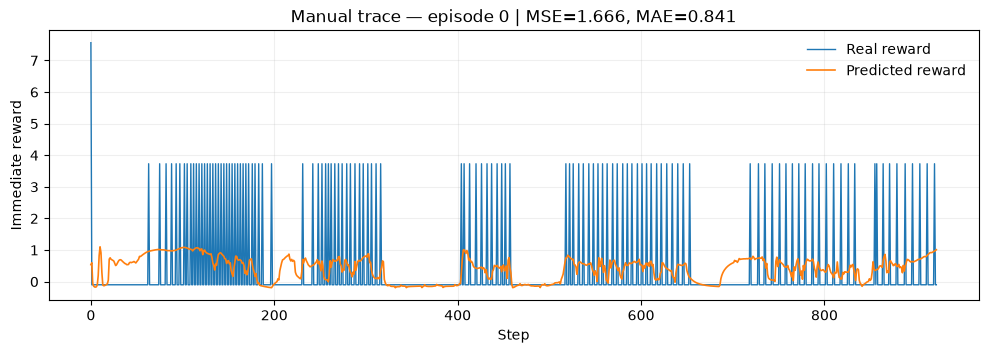

In [5]:
# Print the manual trace in a graphic

LOG_PATH = ROOT / 'runs' / 'evidence' / 'manual_traces' / (CURRENT_MODEL + '_session01.csv')

log = pd.read_csv(LOG_PATH)
episode_id = int(log.episode.max())
trace = log[log.episode == episode_id].copy()

if LOG_PATH.exists():
    episode_id = int(log.episode.iloc[-1])
    trace = log[log.episode == episode_id]
    mse = np.mean((trace.reward_true - trace.reward_pred) ** 2)
    mae = np.mean(np.abs(trace.reward_true - trace.reward_pred))

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(trace.step, trace.reward_true, lw=1.0, label='Real reward')
    ax.plot(trace.step, trace.reward_pred, lw=1.2, label='Predicted reward')
    ax.set(title=f'Manual trace — episode {episode_id} | MSE={mse:.3f}, MAE={mae:.3f}',
           xlabel='Step', ylabel='Immediate reward')
    ax.legend(frameon=False)
    ax.grid(alpha=.2)
    plt.show()

## Manual-trace diagnostic

This is a qualitative distribution-shift check, **not** the thesis benchmark: the episode was human-driven and was not selected from the locked evaluation protocol.

We separate the first 50 frames (startup/camera confound) from steady driving. A reward event is any transition with real reward above the normal CarRacing baseline of `-0.1`.

In [6]:
# Raw comparison
STARTUP_STEPS = 50  # Change only when explicitly documenting a different protocol.

if LOG_PATH.exists():
    trace = log[log.episode == int(log.episode.iloc[-1])].copy()
    startup = trace.step < STARTUP_STEPS
    steady = ~startup
    reward_event = trace.reward_true > -0.1
    baseline = trace.reward_true <= -0.1

    def error_summary(name, mask):
        subset = trace.loc[mask]
        if subset.empty:
            return {'slice': name, 'n': 0, 'mse': np.nan, 'mae': np.nan,
                    'mean_true': np.nan, 'mean_pred': np.nan, 'mean_error': np.nan}
        error = subset.reward_pred - subset.reward_true
        return {
            'slice': name, 'n': len(subset),
            'mse': np.mean(error ** 2), 'mae': np.mean(np.abs(error)),
            'mean_true': subset.reward_true.mean(),
            'mean_pred': subset.reward_pred.mean(),
            'mean_error': error.mean(),  # negative = systematic underprediction
        }

    manual_diagnostic = pd.DataFrame([
        error_summary('all transitions', np.ones(len(trace), dtype=bool)),
        error_summary(f'startup (<{STARTUP_STEPS})', startup),
        error_summary('steady state', steady),
        error_summary('reward events, steady', steady & reward_event),
        error_summary('baseline -0.1, steady', steady & baseline),
    ])
    display(manual_diagnostic.style.format({
        'mse': '{:.3f}', 'mae': '{:.3f}', 'mean_true': '{:.3f}',
        'mean_pred': '{:.3f}', 'mean_error': '{:.3f}',
    }))

,slice,n,mse,mae,mean_true,mean_pred,mean_error
0,all transitions,923,1.666,0.841,0.394,0.399,0.005
1,startup (<50),50,1.383,0.674,0.053,0.434,0.380
2,steady state,873,1.682,0.850,0.413,0.397,-0.017
3,"reward events, steady",537,2.463,1.022,0.735,0.350,-0.385
4,"baseline -0.1, steady",336,0.433,0.576,-0.100,0.472,0.572


In [7]:
# Positive-reward spikes in this trace are typically three steps apart; use the requested three-step causal target average.
SMOOTH_WINDOW = 3
positive_steps = trace.loc[trace.reward_true > 0, 'step'].to_numpy()
positive_gaps = np.diff(positive_steps)
assert len(positive_gaps), 'This trace has too few positive reward events for a rate diagnostic.'
print(f'Positive-reward spacing: median={np.median(positive_gaps):.0f}, IQR={np.quantile(positive_gaps, .25):.0f}–{np.quantile(positive_gaps, .75):.0f} steps; causal window={SMOOTH_WINDOW}.')

# Only the reward target is averaged: mean(r[t-2], r[t-1], r[t]); predictions retain their original scale.
reward_rate = trace.reward_true.rolling(SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW).mean()
rate_valid = reward_rate.notna()
rate_steady = rate_valid & (trace.step >= STARTUP_STEPS)
rate_event = rate_steady & (reward_rate > -0.1)
rate_baseline = rate_steady & (reward_rate <= -0.1)

def rate_summary(name, mask):
    target = reward_rate.loc[mask]
    prediction = trace.loc[mask, 'reward_pred']
    error = prediction - target
    return {
        'slice': name, 'n': len(target),
        'mse': np.mean(error ** 2), 'mae': np.mean(np.abs(error)),
        'mean_true': target.mean(), 'mean_pred': prediction.mean(),
        'mean_error': error.mean(), 'correlation': target.corr(prediction),
    }

reward_rate_diagnostic = pd.DataFrame([
    rate_summary('steady, 3-step reward rate', rate_steady),
    rate_summary('reward events, steady rate', rate_event),
    rate_summary('baseline -0.1, steady rate', rate_baseline),
])
display(reward_rate_diagnostic.style.format({
    'mse': '{:.3f}', 'mae': '{:.3f}', 'mean_true': '{:.3f}', 'mean_pred': '{:.3f}',
    'mean_error': '{:.3f}', 'correlation': '{:.3f}',
}))

Positive-reward spacing: median=5, IQR=4–7 steps; causal window=3.


,slice,n,mse,mae,mean_true,mean_pred,mean_error,correlation
0,"steady, 3-step reward rate",873,0.373,0.502,0.413,0.397,-0.017,0.341
1,"reward events, steady rate",639,0.377,0.497,0.602,0.392,-0.210,0.454
2,"baseline -0.1, steady rate",234,0.363,0.517,-0.100,0.411,0.511,0.408


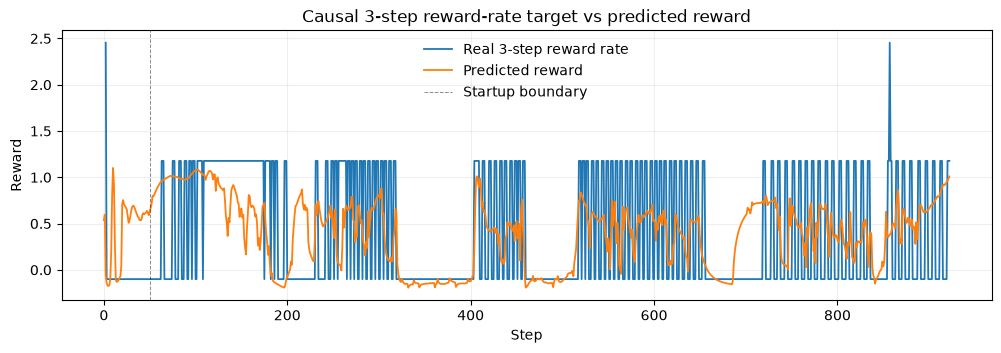

In [8]:
# The raw plot above remains unchanged; this second plot compares the three-step reward target with unnormalised predictions.
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(trace.step, reward_rate, lw=1.3, label='Real 3-step reward rate')
ax.plot(trace.step, trace.reward_pred, lw=1.3, label='Predicted reward')
ax.axvline(STARTUP_STEPS, color='black', lw=.7, ls='--', alpha=.45, label='Startup boundary')
ax.set(title='Causal 3-step reward-rate target vs predicted reward', xlabel='Step', ylabel='Reward')
ax.legend(frameon=False)
ax.grid(alpha=.2)
plt.show()